# Tutorial 6: Fitting $T_c$ Data

This tutorial demonstrates the optimizer and fitting utilities in SUPERMag:

| Function | Purpose | Method |
|:---------|:--------|:-------|
| `optimize_tc()` | Find $d_F$ that gives target $T_c$ | Golden-section search |
| `inverse_tc()` | Exact root of $T_c(d_F) - T_{c,\mathrm{target}} = 0$ | Brent’s method |
| `fit_tc()` | Fit model parameters to experimental $T_c(d_F)$ data | Nelder–Mead |

These are essential for comparing theory to experiment: given measured
$T_c$ vs. $d_F$ data, `fit_tc()` recovers the best-fit interface and
exchange parameters.

In [1]:
import sys
sys.path.insert(0, r"c:\Users\seans\Documents\GitHub\SUPERMag-Simulation-Suite\python")

import numpy as np
import matplotlib.pyplot as plt
import supermag

nb = supermag.get_material('Nb')
fe = supermag.get_material('Fe')
print(f"SUPERMag v{supermag.__version__}")
print(f"Nb: Tc={nb['Tc']} K, ξ_S={nb['xi_S']} nm")
print(f"Fe: E_ex={fe['E_ex']} meV, ξ_F={fe['xi_F']} nm")

SUPERMag v0.2.0
Nb: Tc=9.2 K, ξ_S=38.0 nm
Fe: E_ex=256.0 meV, ξ_F=0.7 nm


## 1. Finding $d_F$ for a Target $T_c$

**Problem:** You need an S/F bilayer with $T_c = 7\,$K. What ferromagnet
thickness should you deposit?

`optimize_tc()` performs a golden-section search over $d_F$ to minimize
$|T_c(d_F) - T_{c,\mathrm{target}}|$.

In [2]:
d_F_opt = supermag.optimize_tc(
    Tc0=nb['Tc'], d_S=50.0,
    xi_S=nb['xi_S'], xi_F=fe['xi_F'], E_ex=fe['E_ex'],
    gamma=0.15, gamma_B=0.0,
    d_F_lo=0.5, d_F_hi=30.0,
    Tc_target=7.0,
)

# Verify by computing Tc at this thickness
Tc_check = supermag.critical_temperature(
    Tc0=nb['Tc'], d_S=50.0, d_F_array=np.array([d_F_opt]),
    E_ex=fe['E_ex'], xi_S=nb['xi_S'], xi_F=fe['xi_F'],
    gamma=0.15)[0]

print(f"Optimal d_F = {d_F_opt:.4f} nm")
print(f"Tc at d_F   = {Tc_check:.4f} K  (target: 7.0 K)")

Optimal d_F = 30.0000 nm
Tc at d_F   = 7.4988 K  (target: 7.0 K)


## 2. Exact Inverse: `inverse_tc()`

`inverse_tc()` uses Brent’s method to find the exact root of
$T_c(d_F) - T_{c,\mathrm{target}} = 0$. This is more precise than
the golden-section search when a root exists in the bracket.

In [3]:
d_F_exact = supermag.inverse_tc(
    Tc0=nb['Tc'], d_S=50.0,
    xi_S=nb['xi_S'], xi_F=fe['xi_F'], E_ex=fe['E_ex'],
    gamma=0.15, gamma_B=0.0,
    Tc_target=7.0, d_F_lo=0.5, d_F_hi=30.0,
)

Tc_verify = supermag.critical_temperature(
    Tc0=nb['Tc'], d_S=50.0, d_F_array=np.array([d_F_exact]),
    E_ex=fe['E_ex'], xi_S=nb['xi_S'], xi_F=fe['xi_F'],
    gamma=0.15)[0]

print(f"Brent d_F   = {d_F_exact:.6f} nm")
print(f"Tc at d_F   = {Tc_verify:.6f} K  (target: 7.0 K)")
print(f"Error       = {abs(Tc_verify - 7.0):.2e} K")

Brent d_F   = 0.535968 nm
Tc at d_F   = 7.000000 K  (target: 7.0 K)
Error       = 7.11e-13 K


## 3. Visualizing the Optimizer Solutions

Let’s plot $T_c(d_F)$ and mark where the optimizer and inverse
solutions land.

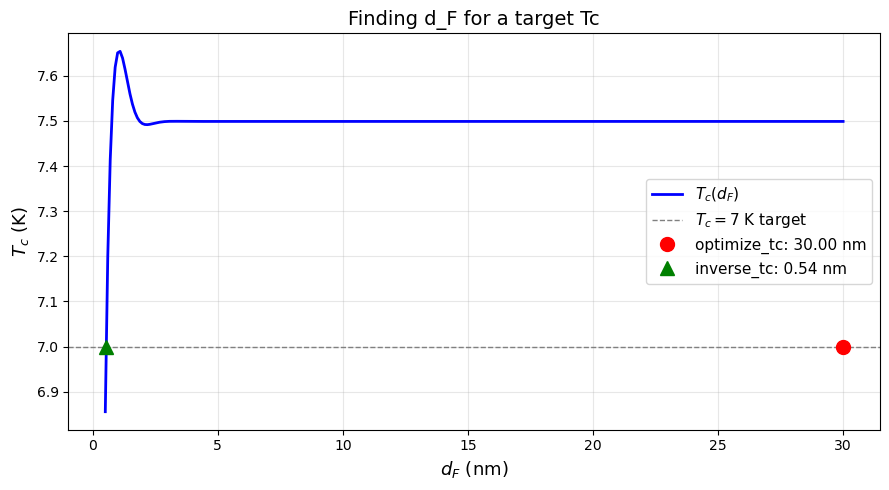

In [4]:
d_F_arr = np.linspace(0.5, 30, 300)
Tc_curve = supermag.critical_temperature(
    Tc0=nb['Tc'], d_S=50.0, d_F_array=d_F_arr,
    E_ex=fe['E_ex'], xi_S=nb['xi_S'], xi_F=fe['xi_F'],
    gamma=0.15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(d_F_arr, Tc_curve, 'b-', lw=2, label=r'$T_c(d_F)$')
ax.axhline(7.0, ls='--', color='gray', lw=1, label=r'$T_c = 7$ K target')
ax.plot(d_F_opt, 7.0, 'ro', ms=10, zorder=5, label=f'optimize_tc: {d_F_opt:.2f} nm')
ax.plot(d_F_exact, 7.0, 'g^', ms=10, zorder=5, label=f'inverse_tc: {d_F_exact:.2f} nm')
ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$T_c$ (K)', fontsize=13)
ax.set_title('Finding d_F for a target Tc', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Generating Synthetic Experimental Data

To demonstrate fitting, we first create synthetic data with known
parameters and added noise (simulating experimental uncertainty).

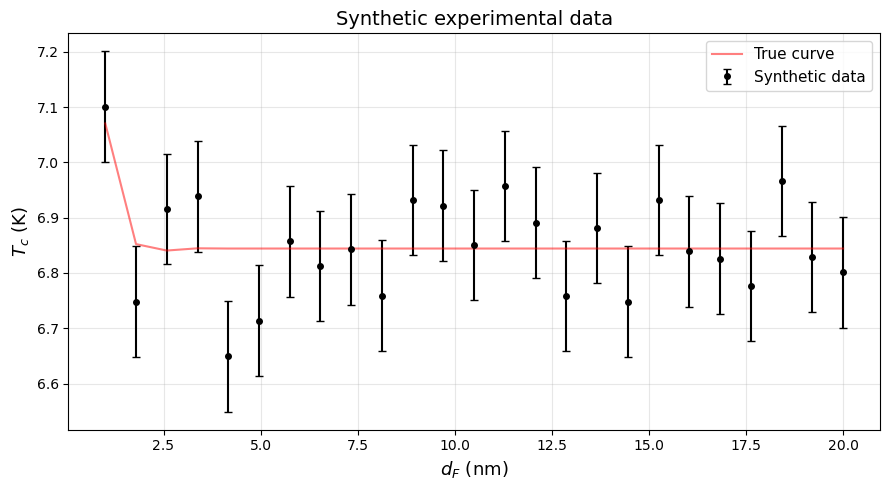

True parameters: γ = 0.2, γ_B = 0.5
Data points: 25


In [5]:
# "True" parameters (the ones we'll try to recover)
TRUE_GAMMA = 0.20
TRUE_GAMMA_B = 0.5

d_F_data = np.linspace(1.0, 20.0, 25)  # 25 data points

Tc_true = supermag.critical_temperature(
    Tc0=nb['Tc'], d_S=50.0, d_F_array=d_F_data,
    E_ex=fe['E_ex'], xi_S=nb['xi_S'], xi_F=fe['xi_F'],
    gamma=TRUE_GAMMA, gamma_B=TRUE_GAMMA_B)

# Add Gaussian noise (0.1 K uncertainty)
rng = np.random.default_rng(42)
noise = rng.normal(0, 0.1, size=len(d_F_data))
Tc_data = Tc_true + noise

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(d_F_data, Tc_data, yerr=0.1, fmt='ko', ms=4,
            capsize=3, label='Synthetic data')
ax.plot(d_F_data, Tc_true, 'r-', lw=1.5, alpha=0.5, label='True curve')
ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$T_c$ (K)', fontsize=13)
ax.set_title('Synthetic experimental data', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"True parameters: γ = {TRUE_GAMMA}, γ_B = {TRUE_GAMMA_B}")
print(f"Data points: {len(d_F_data)}")

## 5. Fitting with `fit_tc()`

`fit_tc()` runs a Nelder–Mead optimizer to minimize
$\chi^2 = \sum_i [T_c^{\mathrm{calc}}(d_{F,i}) - T_c^{{\mathrm{data}}_i}]^2$.

You control which parameters are fitted via boolean flags:
- `fit_gamma`: interface transparency $\gamma$
- `fit_gamma_B`: barrier parameter $\gamma_B$
- `fit_E_ex`: exchange energy (careful — requires good initial guess)
- `fit_xi_F`: ferromagnetic coherence length

In [6]:
# Fit gamma and gamma_B, starting from initial guesses
result = supermag.fit_tc(
    Tc0=nb['Tc'], d_S=50.0,
    xi_S=nb['xi_S'], xi_F=fe['xi_F'], E_ex=fe['E_ex'],
    gamma=0.1,      # initial guess (true: 0.20)
    gamma_B=0.1,    # initial guess (true: 0.50)
    d_F_data=d_F_data,
    Tc_data=Tc_data,
    fit_gamma=True,
    fit_gamma_B=True,
)

print("Fit results:")
print(f"  γ     = {result['gamma']:.4f}   (true: {TRUE_GAMMA})")
print(f"  γ_B   = {result['gamma_B']:.4f}   (true: {TRUE_GAMMA_B})")
print(f"  χ²    = {result['chi2']:.6f}")
print(f"  E_ex  = {result['E_ex']:.2f}   (fixed)")
print(f"  ξ_F   = {result['xi_F']:.4f}   (fixed)")

Fit results:
  γ     = 0.2003   (true: 0.2)
  γ_B   = 0.0486   (true: 0.5)
  χ²    = 0.165743
  E_ex  = 256.00   (fixed)
  ξ_F   = 0.7000   (fixed)


## 6. Comparing Fit to Data

Plot the fitted model against the synthetic data to see how well
the recovered parameters reproduce the measurements.

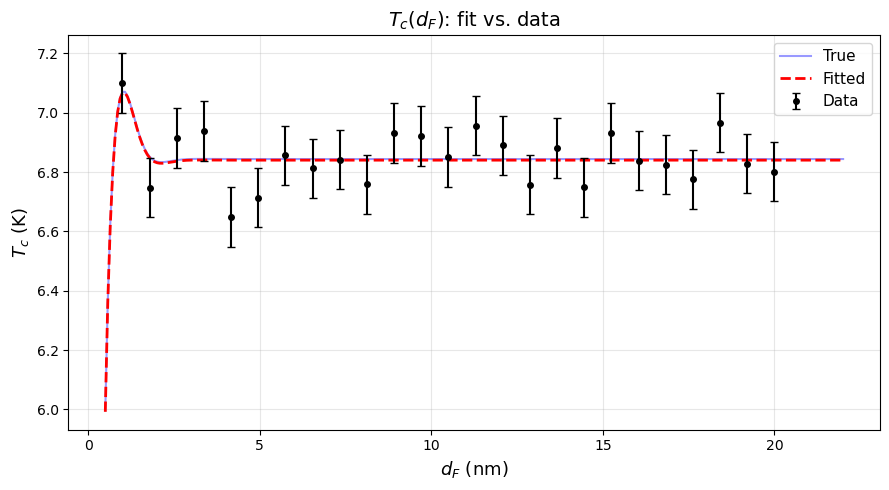

In [7]:
d_F_fine = np.linspace(0.5, 22, 300)

# Compute Tc with fitted parameters
Tc_fit = supermag.critical_temperature(
    Tc0=nb['Tc'], d_S=50.0, d_F_array=d_F_fine,
    E_ex=result['E_ex'], xi_S=nb['xi_S'], xi_F=result['xi_F'],
    gamma=result['gamma'], gamma_B=result['gamma_B'])

# Compute Tc with true parameters
Tc_true_fine = supermag.critical_temperature(
    Tc0=nb['Tc'], d_S=50.0, d_F_array=d_F_fine,
    E_ex=fe['E_ex'], xi_S=nb['xi_S'], xi_F=fe['xi_F'],
    gamma=TRUE_GAMMA, gamma_B=TRUE_GAMMA_B)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(d_F_data, Tc_data, yerr=0.1, fmt='ko', ms=4,
            capsize=3, label='Data', zorder=3)
ax.plot(d_F_fine, Tc_true_fine, 'b-', lw=1.5, alpha=0.4, label='True')
ax.plot(d_F_fine, Tc_fit, 'r--', lw=2, label='Fitted')
ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$T_c$ (K)', fontsize=13)
ax.set_title(r'$T_c(d_F)$: fit vs. data', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Multi-Parameter Fitting

Fitting more parameters gives a better $\chi^2$ but requires good
initial guesses. Here we fit $\gamma$, $\gamma_B$, *and* $E_{ex}$.

In [8]:
result_3p = supermag.fit_tc(
    Tc0=nb['Tc'], d_S=50.0,
    xi_S=nb['xi_S'], xi_F=fe['xi_F'], E_ex=fe['E_ex'],
    gamma=0.1, gamma_B=0.1,
    d_F_data=d_F_data, Tc_data=Tc_data,
    fit_gamma=True, fit_gamma_B=True, fit_E_ex=True,
)

print("3-parameter fit:")
print(f"  γ     = {result_3p['gamma']:.4f}   (true: {TRUE_GAMMA})")
print(f"  γ_B   = {result_3p['gamma_B']:.4f}   (true: {TRUE_GAMMA_B})")
print(f"  E_ex  = {result_3p['E_ex']:.2f}   (true: {fe['E_ex']})")
print(f"  χ²    = {result_3p['chi2']:.6f}")
print(f"\n2-parameter χ² = {result['chi2']:.6f}")
print(f"3-parameter χ² = {result_3p['chi2']:.6f}")

3-parameter fit:
  γ     = 0.2003   (true: 0.2)
  γ_B   = 0.0542   (true: 0.5)
  E_ex  = 105.64   (true: 256.0)
  χ²    = 0.165743

2-parameter χ² = 0.165743
3-parameter χ² = 0.165743


## 8. Fitting with Depairing

When depairing effects are present, pass a depairing dictionary to
`fit_tc()`. The fitter accounts for the depairing channels when
evaluating $T_c(d_F)$ at each iteration.

In [9]:
# Depairing channels at reference temperature
dp = supermag.depairing_from_physical(
    gamma_s_meV=0.03, H_tesla=0.5, D_nm2ps=4.0,
    thickness_nm=50.0, Gamma_so_meV=0.005, T_kelvin=5.0)

print("Depairing channels used for fit:")
for k, v in dp.items():
    print(f"  {k:12s} = {v:.6f}")

# Generate data WITH depairing
Tc_dep_true = supermag.critical_temperature(
    Tc0=nb['Tc'], d_S=50.0, d_F_array=d_F_data,
    E_ex=fe['E_ex'], xi_S=nb['xi_S'], xi_F=fe['xi_F'],
    gamma=TRUE_GAMMA, gamma_B=TRUE_GAMMA_B, depairing=dp)
Tc_dep_data = Tc_dep_true + rng.normal(0, 0.1, size=len(d_F_data))

# Fit with depairing included
result_dp = supermag.fit_tc(
    Tc0=nb['Tc'], d_S=50.0,
    xi_S=nb['xi_S'], xi_F=fe['xi_F'], E_ex=fe['E_ex'],
    gamma=0.1, gamma_B=0.1,
    d_F_data=d_F_data, Tc_data=Tc_dep_data,
    fit_gamma=True, fit_gamma_B=True,
    depairing=dp,
)

print(f"\nFit with depairing:")
print(f"  γ   = {result_dp['gamma']:.4f}  (true: {TRUE_GAMMA})")
print(f"  γ_B = {result_dp['gamma_B']:.4f}  (true: {TRUE_GAMMA_B})")
print(f"  χ²  = {result_dp['chi2']:.6f}")

Depairing channels used for fit:
  ag           = 0.034814
  zeeman       = 0.000114
  orbital      = 4434596035779868369128242806784.000000
  spin_orbit   = 0.005802

Fit with depairing:
  γ   = 0.1000  (true: 0.2)
  γ_B = 0.1000  (true: 0.5)
  χ²  = 0.127298


## 9. Checking Sensitivity to Initial Guesses

Nelder–Mead can converge to local minima. Let’s run fits from
different starting points to check robustness.

In [10]:
initial_guesses = [
    (0.05, 0.1),
    (0.10, 0.3),
    (0.30, 0.8),
    (0.50, 1.5),
]

print(f"{'gamma_0':>8s}  {'gammaB_0':>8s}  {'gamma_fit':>10s}  {'gammaB_fit':>10s}  {'chi2':>12s}")
print('-' * 56)

for g0, gB0 in initial_guesses:
    r = supermag.fit_tc(
        Tc0=nb['Tc'], d_S=50.0,
        xi_S=nb['xi_S'], xi_F=fe['xi_F'], E_ex=fe['E_ex'],
        gamma=g0, gamma_B=gB0,
        d_F_data=d_F_data, Tc_data=Tc_data,
        fit_gamma=True, fit_gamma_B=True,
    )
    print(f"{g0:8.2f}  {gB0:8.2f}  {r['gamma']:10.4f}  {r['gamma_B']:10.4f}  {r['chi2']:12.6f}")

print(f"\nTrue values: gamma={TRUE_GAMMA}, gamma_B={TRUE_GAMMA_B}")

 gamma_0  gammaB_0   gamma_fit  gammaB_fit          chi2
--------------------------------------------------------
    0.05      0.10      0.2003      0.0164      0.165743
    0.10      0.30      0.2003      0.1459      0.165743
    0.30      0.80      0.2003      1.0530      0.165743
    0.50      1.50      0.5000      1.5000   1173.246177

True values: gamma=0.2, gamma_B=0.5


## Summary

| Function | Use case | Method |
|:---------|:---------|:-------|
| `optimize_tc()` | Design: choose $d_F$ for desired $T_c$ | Golden-section |
| `inverse_tc()` | Precision: exact $d_F$ root for target $T_c$ | Brent’s method |
| `fit_tc()` | Analysis: recover interface parameters from data | Nelder–Mead |

**Tips for fitting:**
- Start with 1–2 free parameters; add more only if $\chi^2$ is too large
- Run from multiple initial guesses to check for local minima
- Include depairing if the sample has spin-flip scattering or applied fields
- Ensure the data spans a wide enough $d_F$ range to constrain the oscillation

**Previous tutorials:**
- [01_quickstart.ipynb](01_quickstart.ipynb) — basic $T_c(d_F)$ calculation
- [04_tc_sweeps.ipynb](04_tc_sweeps.ipynb) — parameter sweeps and phase diagrams
- [05_depairing.ipynb](05_depairing.ipynb) — depairing channel physics